# GW Dephasing Surrogate — v1

Quick-and-dirty end-to-end pipeline:
parse CSVs → normalize frequency to x ∈ [0,1] → resample onto common grid → log-transform → PCA basis on train only → MLP from (4 params) → coefficients → reconstruct.

Using natural log throughout (per agreed deviation from the project context doc).

In [1]:
import os, glob, re
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

torch.manual_seed(0)
np.random.seed(0)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu"))
print("device:", DEVICE)

device: mps


## 1. Load raw data

In [2]:
DATA_DIR = "data"
files = sorted(glob.glob(os.path.join(DATA_DIR, "dephasing_sample_*.csv")),
               key=lambda p: int(re.search(r"_(\d+)\.csv$", p).group(1)))
print("n files:", len(files))

def parse_file(path):
    with open(path) as fh:
        lines = fh.readlines()
    params = {}
    for item in lines[0].strip().split(","):
        k, v = item.split("=")
        params[k.strip()] = float(v)
    data = np.loadtxt(lines[2:], delimiter=",")
    return params, data[:, 0], data[:, 1]  # f [Hz], dPh [rad]

# Stack into arrays. m1, m2, rhosp, gsp + per-system (f, dPh) lists.
m1  = np.empty(len(files))
m2  = np.empty(len(files))
rho = np.empty(len(files))
gsp = np.empty(len(files))
fs, dphis = [], []
for i, fp in enumerate(files):
    p, f, d = parse_file(fp)
    m1[i], m2[i], rho[i], gsp[i] = p["m1"], p["m2"], p["rhosp"], p["gsp"]
    fs.append(f); dphis.append(d)

print("m1   :", m1.min(), m1.max())
print("m2   :", m2.min(), m2.max())
print("rho6 :", rho.min(), rho.max())
print("gsp  :", gsp.min(), gsp.max())
print("points/curve (first 5):", [len(d) for d in dphis[:5]])

n files: 10000
m1   : 1001.003 999688.526
m2   : 3.001 99.995
rho6 : 10.009 9993.165
gsp  : 2.0 2.5
points/curve (first 5): [200, 200, 200, 200, 200]


## 2. Frequency normalization → x ∈ [0, 1]

- f_c = f_ISCO at total mass M (Schwarzschild ISCO, GW frequency = 2 × orbital): f_ISCO = c³ / (6^{3/2} π G M).
- f_τ: invert leading-order vacuum chirp time τ(f) = (5/256)(πf)^{-8/3} (G𝓜/c³)^{-5/3} for a chosen lookback window τ, where 𝓜 is the chirp mass.
- x = (f − f_c) / (f_τ − f_c) (corrected denominator from Cole et al. G1 typo).

Per supervisor guidance, using **τ = 4 years** instead of the original 10. Shorter τ → larger f_τ → fewer systems' data falls short of the x=1 anchor, which mitigates the upper-range truncation issue.

In [3]:
# Constants (SI)
G    = 6.67430e-11
C    = 2.99792458e8
MSUN = 1.98892e30
YR   = 365.25 * 86400.0

# Lookback window for the x=1 anchor: changed from 10 yr -> 4 yr per supervisor.
TAU_YR = 4.0

def f_isco(m1_msun, m2_msun):
    M = (m1_msun + m2_msun) * MSUN
    return C**3 / (6**1.5 * np.pi * G * M)

def f_tau(m1_msun, m2_msun, tau_sec=TAU_YR * YR):
    Mc = (m1_msun * m2_msun)**(3/5) / (m1_msun + m2_msun)**(1/5) * MSUN
    # f = (1/pi) * (5 / (256 tau))**(3/8) * (G Mc / c^3)**(-5/8)
    return (1.0 / np.pi) * (5.0 / (256.0 * tau_sec))**(3/8) * (G * Mc / C**3)**(-5/8)

fc    = f_isco(m1, m2)
f_tau_arr = f_tau(m1, m2)
print(f"fc      range: {fc.min():.4e}  {fc.max():.4e}")
print(f"f_{TAU_YR:g}yr  range: {f_tau_arr.min():.4e}  {f_tau_arr.max():.4e}")

# Sanity: how does each system's actual f-range overlap [f_tau, fc]?
fmin_data = np.array([f[0]  for f in fs])
fmax_data = np.array([f[-1] for f in fs])
print(f"\nfmin_data / f_tau (median): {np.median(fmin_data / f_tau_arr):.4f}")
print(f"fmax_data / fc    (median): {np.median(fmax_data / fc):.4f}")

fc      range: 4.3973e-03  4.3774e+00
f_4yr  range: 7.8091e-04  1.6024e-02

fmin_data / f_tau (median): 0.9199
fmax_data / fc    (median): 1.0010


In [4]:
# Build x for each system, drop the trailing dPh=0 point at merger, take ln(dPh).
# Every file has exactly one zero (the last entry, by definition of dephasing at merger),
# so this is safe and keeps a uniform pre-resample length of 199 across all systems.
assert all((d[-1] == 0) and (d[:-1] > 0).all() for d in dphis), "unexpected zero pattern"

xs, log_dphis = [], []
for i in range(len(files)):
    x = (fs[i][:-1] - fc[i]) / (f_tau_arr[i] - fc[i])
    xs.append(x)
    log_dphis.append(np.log(dphis[i][:-1]))

assert all(len(x) == 199 for x in xs)  # shape consistency check before resampling

# Look at x ranges
xmins = np.array([x.min() for x in xs])
xmaxs = np.array([x.max() for x in xs])
print("x.min  -- min:", xmins.min(), "median:", np.median(xmins), "max:", xmins.max())
print("x.max  -- min:", xmaxs.min(), "median:", np.median(xmaxs), "max:", xmaxs.max())

x.min  -- min: -0.1070374883609459 median: 0.015612776196193605 max: 0.023710501013420125
x.max  -- min: 1.0000911344308259 median: 1.0021990088366244 max: 1.1511184086282258


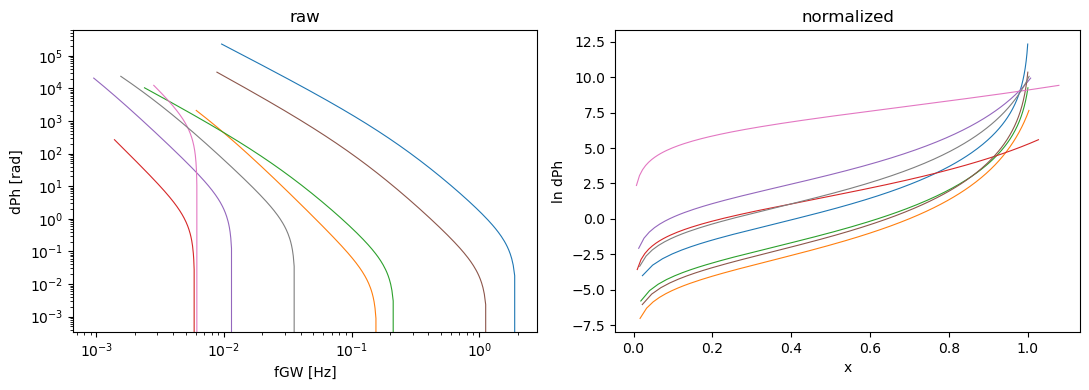

In [5]:
# Quick visualization of a few raw curves in (x, log dPh).
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for i in np.random.choice(len(files), 8, replace=False):
    ax[0].plot(fs[i], dphis[i], lw=0.8)
    ax[1].plot(xs[i], log_dphis[i], lw=0.8)
ax[0].set(xscale="log", yscale="log", xlabel="fGW [Hz]", ylabel="dPh [rad]", title="raw")
ax[1].set(xlabel="x", ylabel="ln dPh", title="normalized")
plt.tight_layout(); plt.show()

## 3. Resample onto common x-grid

Each system has its own x-range. I'll use linear interpolation on a uniform grid in x over the *intersection* of all systems' x-ranges (so no extrapolation). Curves outside the grid endpoints are simply not informative.

common x-grid: [0.0237, 1.0001], 200 points
Y shape: (10000, 200)


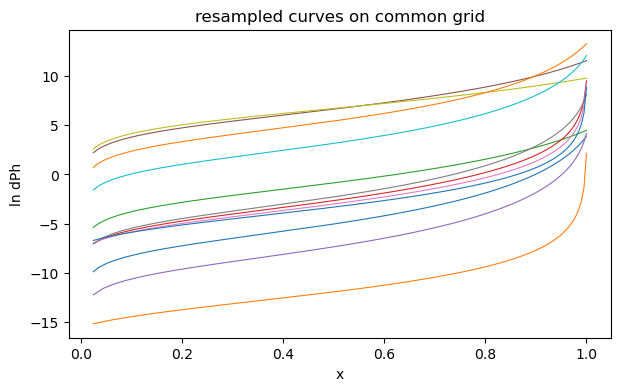

In [6]:
X_LO = float(np.max(xmins))
X_HI = float(np.min(xmaxs))
N_X  = 200
x_grid = np.linspace(X_LO, X_HI, N_X)
print(f"common x-grid: [{X_LO:.4f}, {X_HI:.4f}], {N_X} points")

# Note: x decreases as the inspiral progresses (x=1 at f_tau, x=0 at merger),
# so xs[i] is monotonically *decreasing*. np.interp requires increasing xp,
# so flip both arrays before interpolating.
Y = np.empty((len(files), N_X))
for i in range(len(files)):
    xi = xs[i][::-1]
    yi = log_dphis[i][::-1]
    assert np.all(np.diff(xi) > 0), f"x not strictly increasing after flip (system {i})"
    Y[i] = np.interp(x_grid, xi, yi)
print("Y shape:", Y.shape)

# sanity plot
fig, ax = plt.subplots(figsize=(7,4))
for i in np.random.choice(len(files), 12, replace=False):
    ax.plot(x_grid, Y[i], lw=0.8)
ax.set(xlabel="x", ylabel="ln dPh", title="resampled curves on common grid")
plt.show()

## 4. Inputs: log-transform and standardize

- log m₁, log m₂, log ρ₆ (natural log).
- γ_s linear.
- Then standardize all four to zero mean / unit std using **training** statistics.

In [7]:
theta_raw = np.column_stack([np.log(m1), np.log(m2), np.log(rho), gsp])
print("theta_raw shape:", theta_raw.shape)

idx = np.arange(len(files))
idx_trainval, idx_test = train_test_split(idx, test_size=0.10, random_state=0)
idx_train, idx_val     = train_test_split(idx_trainval, test_size=1/9, random_state=0)  # 0.10 of total
print(f"train/val/test = {len(idx_train)}/{len(idx_val)}/{len(idx_test)}")

theta_mu  = theta_raw[idx_train].mean(0)
theta_std = theta_raw[idx_train].std(0)
theta = (theta_raw - theta_mu) / theta_std

theta_raw shape: (10000, 4)
train/val/test = 8000/1000/1000


## 5. Autoencoder basis (train only) → encode all curves

Replacing PCA with a small autoencoder that has the *same latent dimensionality* K. The AE has more parameters (encoder + decoder MLP weights) but is constrained to compress every curve through a K-dimensional bottleneck, exactly like PCA — the difference is that the encoder/decoder are nonlinear, so the resulting "basis" is curved rather than a flat subspace.

Once trained, we treat the encoded latents as our coefficients and proceed identically to the PCA pipeline (standardize, train MLP from 4 params → K latents, decode via the trained decoder at inference time).

In [ ]:
K = 24

# Center the curves on the training mean so the AE only has to learn shape variation.
Y_mean = Y[idx_train].mean(0)
Y_c    = Y - Y_mean  # all curves, centered

class Autoencoder(nn.Module):
    def __init__(self, d_in=N_X, d_latent=K, width=256):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(d_in, width),  nn.ReLU(),
            nn.Linear(width, width//2), nn.ReLU(),
            nn.Linear(width//2, d_latent),
        )
        self.decoder = nn.Sequential(
            nn.Linear(d_latent, width//2), nn.ReLU(),
            nn.Linear(width//2, width),    nn.ReLU(),
            nn.Linear(width, d_in),
        )
    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z), z

def to_t(a): return torch.as_tensor(a, dtype=torch.float32, device=DEVICE)

Y_tr_t = to_t(Y_c[idx_train])
Y_va_t = to_t(Y_c[idx_val])

ae = Autoencoder().to(DEVICE)
ae_opt = torch.optim.Adam(ae.parameters(), lr=1e-3)
ae_loss_fn = nn.MSELoss()

AE_EPOCHS = 2000
AE_BATCH  = 256

best_va_ae = float("inf"); best_state_ae = None
ae_hist = {"train": [], "val": []}
n_tr = Y_tr_t.shape[0]

for epoch in range(AE_EPOCHS):
    ae.train()
    perm = torch.randperm(n_tr, device=DEVICE)
    losses = []
    for s in range(0, n_tr, AE_BATCH):
        b = perm[s:s+AE_BATCH]
        ae_opt.zero_grad()
        recon, _ = ae(Y_tr_t[b])
        loss = ae_loss_fn(recon, Y_tr_t[b])
        loss.backward(); ae_opt.step()
        losses.append(loss.item())
    ae.eval()
    with torch.no_grad():
        recon_va, _ = ae(Y_va_t)
        va = ae_loss_fn(recon_va, Y_va_t).item()
    ae_hist["train"].append(float(np.mean(losses))); ae_hist["val"].append(va)
    if va < best_va_ae - 1e-7:
        best_va_ae = va
        best_state_ae = {k: v.detach().clone() for k, v in ae.state_dict().items()}
    if epoch % 100 == 0:
        print(f"AE epoch {epoch:4d}  train {ae_hist['train'][-1]:.4e}  val {va:.4e}")

ae.load_state_dict(best_state_ae)
print("AE best val MSE (centered):", best_va_ae)

# Encode every curve to get coefficients (analog of pca.transform).
ae.eval()
with torch.no_grad():
    _, z_all = ae(to_t(Y_c))
coeffs = z_all.cpu().numpy()  # (N, K)

# Standardize coefficients using training stats — same convention as the PCA pipeline.
c_mu  = coeffs[idx_train].mean(0)
c_std = coeffs[idx_train].std(0)
coeffs_n = (coeffs - c_mu) / c_std
print("coeffs shape:", coeffs.shape)

# Sanity: AE reconstruction error in curve space on test set (independent of MLP).
with torch.no_grad():
    recon_te, _ = ae(to_t(Y_c[idx_test]))
ae_only_err = (recon_te.cpu().numpy() - Y_c[idx_test])
ae_floor = np.median(np.sqrt((ae_only_err**2).mean(axis=1)))
print(f"AE-only test recon RMSE in ln(dPh): "
      f"median {ae_floor:.3e}")

AE epoch    0  train 5.0575e+00  val 5.2605e-01
AE epoch  100  train 6.3787e-03  val 1.4390e-03
AE epoch  200  train 1.3004e-04  val 1.1644e-04
AE epoch  300  train 1.7636e-04  val 2.9448e-04
AE epoch  400  train 1.0321e-04  val 7.9169e-05
AE epoch  500  train 6.4523e-05  val 6.4637e-05
AE epoch  600  train 9.9861e-04  val 3.8310e-04
AE epoch  700  train 8.7336e-05  val 6.1114e-05
AE epoch  800  train 2.7135e-03  val 2.2753e-03
AE epoch  900  train 3.6460e-03  val 1.8170e-03
AE epoch 1000  train 4.9816e-04  val 4.7861e-04
AE epoch 1100  train 2.1576e-05  val 4.5272e-05
AE epoch 1200  train 4.3008e-04  val 8.3789e-04
AE epoch 1300  train 1.4162e-04  val 8.8576e-05
AE epoch 1400  train 1.5948e-05  val 1.8059e-05
AE epoch 1500  train 5.7001e-05  val 2.5335e-05
AE epoch 1600  train 3.4123e-05  val 2.7940e-05
AE epoch 1700  train 1.3129e-04  val 1.9071e-04
AE epoch 1800  train 1.2575e-04  val 2.1747e-04
AE epoch 1900  train 5.4086e-05  val 5.6184e-05
AE best val MSE (centered): 1.5332059774

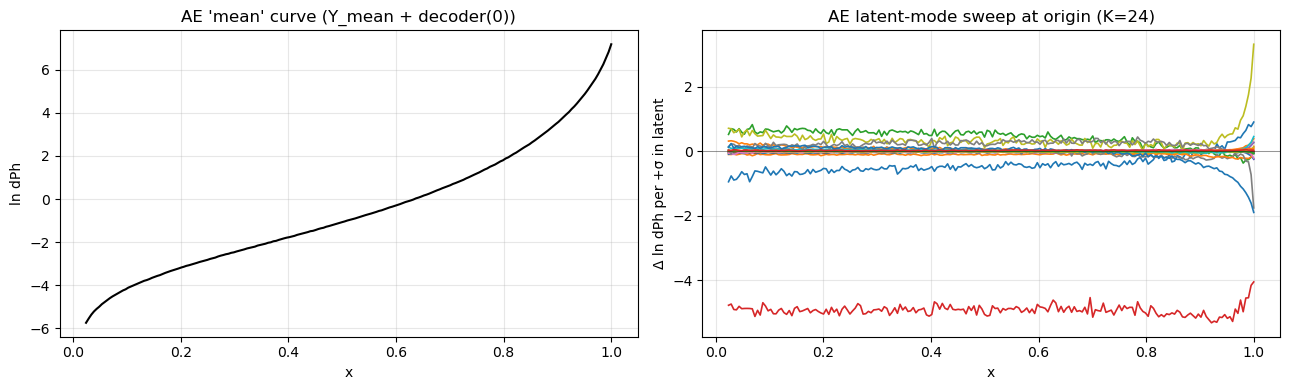

In [10]:
# Visualize the AE "basis": the mean curve, plus what each latent dimension does
# to the decoded output when perturbed around the latent origin. This is the
# nonlinear analog of PCA components — it's a *local* picture (the decoder is
# nonlinear, so the effective basis varies across the latent space), but it
# gives a useful sense of what each latent dim controls.
@torch.no_grad()
def decode(z_arr):
    return ae.decoder(to_t(z_arr)).cpu().numpy()

z0 = np.zeros((1, K))
decoded_origin = decode(z0)[0]  # decoded ln dPh (centered) at latent origin

# Use training-data std of each latent dim as the perturbation scale.
z_std = coeffs[idx_train].std(0)
SWEEP = 2.0  # +/- 2 sigma

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(x_grid, Y_mean + decoded_origin, "k-", lw=1.5)
axes[0].set(xlabel="x", ylabel="ln dPh",
            title="AE 'mean' curve (Y_mean + decoder(0))")
axes[0].grid(alpha=0.3)

for k in range(K):
    zp = z0.copy(); zp[0, k] = +SWEEP * z_std[k]
    zm = z0.copy(); zm[0, k] = -SWEEP * z_std[k]
    delta = (decode(zp)[0] - decode(zm)[0]) / 2.0  # half the +/- range
    axes[1].plot(x_grid, delta, lw=1.2,
                 label=f"latent {k+1}  (σ={z_std[k]:.3g})")
axes[1].axhline(0, color="k", lw=0.5, alpha=0.5)
axes[1].set(xlabel="x", ylabel="Δ ln dPh per +σ in latent",
            title=f"AE latent-mode sweep at origin (K={K})")
axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

## 6. MLP: 4 params → K coefficients

In [11]:
class MLP(nn.Module):
    def __init__(self, d_in=4, d_out=K, width=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_in, width), nn.ReLU(),
            nn.Linear(width, width), nn.ReLU(),
            nn.Linear(width, width), nn.ReLU(),
            nn.Linear(width, d_out),
        )
    def forward(self, x): return self.net(x)

def to_t(a): return torch.as_tensor(a, dtype=torch.float32, device=DEVICE)

X_tr, y_tr = to_t(theta[idx_train]), to_t(coeffs_n[idx_train])
X_va, y_va = to_t(theta[idx_val]),   to_t(coeffs_n[idx_val])
X_te, y_te = to_t(theta[idx_test]),  to_t(coeffs_n[idx_test])

model = MLP().to(DEVICE)
opt = torch.optim.Adam(model.parameters(), lr=1e-4)
loss_fn = nn.MSELoss()

EPOCHS = 2500
BATCH  = 1000

best_va = float("inf"); best_state = None
hist = {"train": [], "val": []}
n_tr = X_tr.shape[0]

for epoch in range(EPOCHS):
    model.train()
    perm = torch.randperm(n_tr, device=DEVICE)
    losses = []
    for s in range(0, n_tr, BATCH):
        b = perm[s:s+BATCH]
        opt.zero_grad()
        pred = model(X_tr[b])
        loss = loss_fn(pred, y_tr[b])
        loss.backward(); opt.step()
        losses.append(loss.item())
    model.eval()
    with torch.no_grad():
        va = loss_fn(model(X_va), y_va).item()
    hist["train"].append(float(np.mean(losses))); hist["val"].append(va)
    if va < best_va - 1e-6:
        best_va = va; best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
    if epoch % 100 == 0:
        print(f"epoch {epoch:4d}  train {hist['train'][-1]:.4e}  val {va:.4e}")

model.load_state_dict(best_state)
print("loaded best model, val MSE =", best_va)

epoch    0  train 9.9376e-01  val 9.7602e-01
epoch  100  train 2.0001e-02  val 1.9143e-02
epoch  200  train 7.6778e-03  val 7.3548e-03
epoch  300  train 3.8556e-03  val 3.8800e-03
epoch  400  train 2.2427e-03  val 2.3483e-03
epoch  500  train 1.5615e-03  val 1.6520e-03
epoch  600  train 1.2223e-03  val 1.3310e-03
epoch  700  train 1.0097e-03  val 1.1151e-03
epoch  800  train 8.5767e-04  val 9.8145e-04
epoch  900  train 7.6179e-04  val 8.5891e-04
epoch 1000  train 6.7081e-04  val 7.8099e-04
epoch 1100  train 6.0020e-04  val 7.1544e-04
epoch 1200  train 5.4579e-04  val 6.6167e-04
epoch 1300  train 4.9907e-04  val 6.1591e-04
epoch 1400  train 4.6061e-04  val 5.7546e-04
epoch 1500  train 4.3159e-04  val 5.6098e-04
epoch 1600  train 3.9162e-04  val 5.1205e-04
epoch 1700  train 3.7120e-04  val 5.0023e-04
epoch 1800  train 3.5792e-04  val 4.7041e-04
epoch 1900  train 3.2971e-04  val 4.5277e-04
epoch 2000  train 3.1894e-04  val 4.3571e-04
epoch 2100  train 3.1594e-04  val 4.4378e-04
epoch 2200

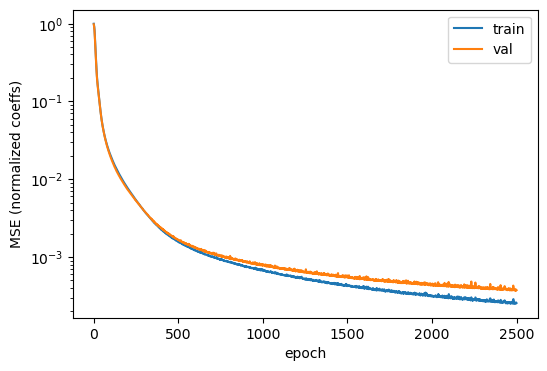

In [12]:
fig, ax = plt.subplots(figsize=(6,4))
ax.plot(hist["train"], label="train")
ax.plot(hist["val"], label="val")
ax.set(yscale="log", xlabel="epoch", ylabel="MSE (normalized coeffs)")
ax.legend(); plt.show()

## 7. Evaluation

In [ ]:
@torch.no_grad()
def predict_curves(theta_arr_norm):
    model.eval(); ae.eval()
    c_n = model(to_t(theta_arr_norm)).cpu().numpy()
    c   = c_n * c_std + c_mu                       # un-standardize back to AE-latent scale
    decoded = ae.decoder(to_t(c)).cpu().numpy()    # centered ln dPh prediction
    Y_hat = decoded + Y_mean                       # add training-mean curve back
    return c, Y_hat

# coefficient-space error (in unnormalized coeff units)
c_te_pred, Y_te_pred = predict_curves(theta[idx_test])
c_te_true            = coeffs[idx_test]
Y_te_true            = Y[idx_test]

coef_mse = ((c_te_pred - c_te_true)**2).mean()
print(f"test coefficient MSE          : {coef_mse:.4e}")

# curve-space error in ln dPh
err = Y_te_pred - Y_te_true
rmse_per_curve = np.sqrt((err**2).mean(axis=1))  # ln-units
print(f"test curve RMSE in ln(dPh)    : median {np.median(rmse_per_curve):.3e}, "
      f"mean {rmse_per_curve.mean():.3e}, p95 {np.quantile(rmse_per_curve, 0.95):.3e}")

# Also report a "fractional" sense: exp(rmse) − 1 ≈ multiplicative error on dPh.
print(f"≈ multiplicative error on dPh : median {np.exp(np.median(rmse_per_curve))-1:.2%}")

print(f"model error: {np.mean(rmse_per_curve) - ae_floor:.3e} (model error above autoencoder floor)")

test coefficient MSE          : 1.3465e-03
test curve RMSE in ln(dPh)    : median 1.536e-02, mean 1.923e-02, p95 4.589e-02
≈ multiplicative error on dPh : median 1.55%
model error: 1.601e-02 (model error above autoencoder floor)


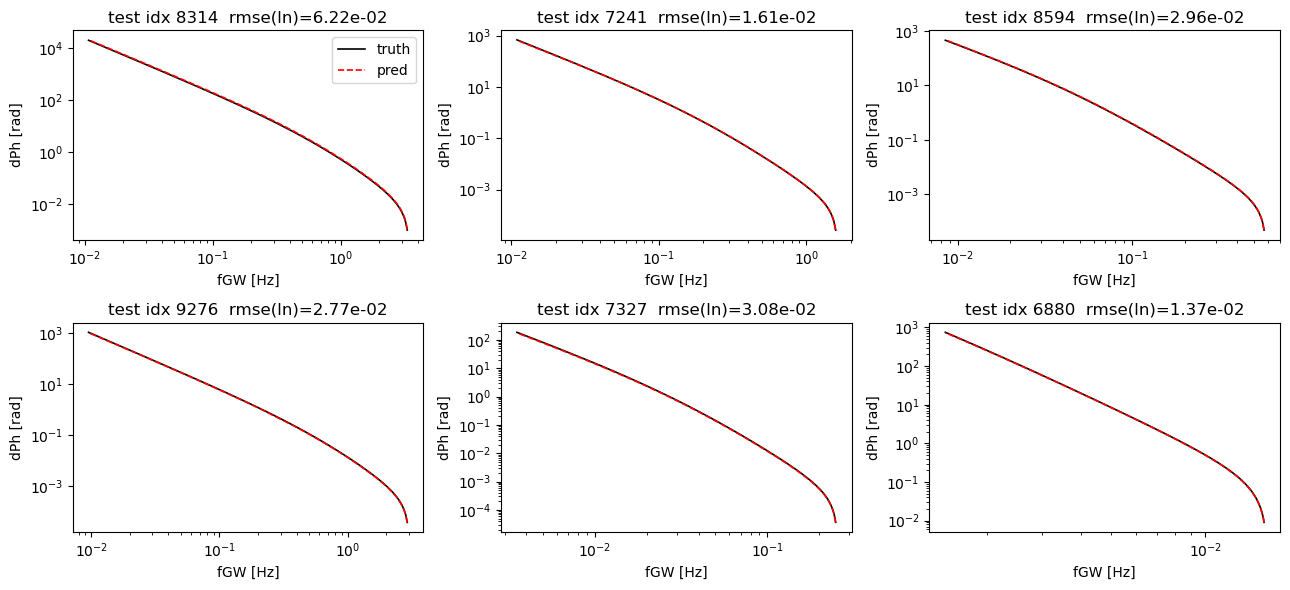

In [18]:
# Visualize a few test predictions vs truth, in physical (f, dPh) space.
# Per-system inverse mapping: f = x * (f_tau - f_c) + f_c, then dPh = exp(ln dPh).
# Each test system has its own f-grid because (f_c, f_tau) depend on (m1, m2).
fig, axes = plt.subplots(2, 3, figsize=(13, 6))
sel = np.random.choice(len(idx_test), 6, replace=False)
for ax, j in zip(axes.flat, sel):
    sys_i = idx_test[j]
    f_axis = x_grid * (f_tau_arr[sys_i] - fc[sys_i]) + fc[sys_i]
    dphi_true = np.exp(Y_te_true[j])
    dphi_pred = np.exp(Y_te_pred[j])
    ax.plot(f_axis, dphi_true, "k-",  lw=1.2, label="truth")
    ax.plot(f_axis, dphi_pred, "r--", lw=1.2, label="pred")
    ax.set(xscale="log", yscale="log",
           xlabel="fGW [Hz]", ylabel="dPh [rad]",
           title=f"test idx {sys_i}  rmse(ln)={rmse_per_curve[j]:.2e}")
axes[0,0].legend()
plt.tight_layout(); plt.show()

### Slice errors by parameter region

In [19]:
# Bin the test set by each input parameter and report median curve RMSE per bin.
def slice_report(values, name, n_bins=5):
    edges = np.quantile(values, np.linspace(0, 1, n_bins+1))
    print(f"\n--- {name} ---")
    for i in range(n_bins):
        lo, hi = edges[i], edges[i+1]
        m = (values >= lo) & (values <= hi if i == n_bins-1 else values < hi)
        if m.sum() == 0: continue
        print(f"  [{lo:.3g}, {hi:.3g}]  n={m.sum():4d}  median rmse(ln) = {np.median(rmse_per_curve[m]):.3e}")

slice_report(m1[idx_test],  "m1")
slice_report(m2[idx_test],  "m2")
slice_report(rho[idx_test], "rho6")
slice_report(gsp[idx_test], "gamma_s")


--- m1 ---
  [1e+03, 4.51e+03]  n= 200  median rmse(ln) = 1.691e-02
  [4.51e+03, 1.9e+04]  n= 200  median rmse(ln) = 1.691e-02
  [1.9e+04, 6.09e+04]  n= 200  median rmse(ln) = 1.584e-02
  [6.09e+04, 2.47e+05]  n= 200  median rmse(ln) = 1.404e-02
  [2.47e+05, 9.91e+05]  n= 200  median rmse(ln) = 1.248e-02

--- m2 ---
  [3.01, 5.99]  n= 200  median rmse(ln) = 1.648e-02
  [5.99, 11.8]  n= 200  median rmse(ln) = 1.345e-02
  [11.8, 24.2]  n= 200  median rmse(ln) = 1.377e-02
  [24.2, 48.2]  n= 200  median rmse(ln) = 1.718e-02
  [48.2, 99.8]  n= 200  median rmse(ln) = 1.583e-02

--- rho6 ---
  [10.1, 38.4]  n= 200  median rmse(ln) = 1.565e-02
  [38.4, 160]  n= 200  median rmse(ln) = 1.514e-02
  [160, 602]  n= 200  median rmse(ln) = 1.584e-02
  [602, 2.59e+03]  n= 200  median rmse(ln) = 1.286e-02
  [2.59e+03, 9.99e+03]  n= 200  median rmse(ln) = 1.671e-02

--- gamma_s ---
  [2, 2.11]  n= 199  median rmse(ln) = 1.753e-02
  [2.11, 2.22]  n= 200  median rmse(ln) = 1.677e-02
  [2.22, 2.31]  n= 20

# Plan

* 4 years instead of 10
* calculate mismatch
* plot mismatch vs rmse
* plot mismatch heatmaps (diagonal plot)
* improve the network (size, layers, etc)